# **1. Perkenalan Dataset**

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

**Dataset yang digunakan:**
Pada eksperimen ini, digunakan dataset "Mobile Price Classification" dari Kaggle. Dataset ini berjenis tabular (CSV) dengan distribusi kelas yang seimbang dan jumlah baris yang sesuai dengan kriteria (2000 baris), sehingga sangat ideal untuk klasifikasi Machine Learning tradisional.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import os
from google.colab import files

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
print("--- 1. UPLOAD KREDENSIAL KAGGLE ---")
print("Silakan upload file kaggle.json kamu di bawah ini:")

uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Kredensial berhasil disetup dengan aman!")

print("\n--- 2. SETUP FOLDER & DOWNLOAD DATASET ---")
os.makedirs('mobile_price_raw', exist_ok=True)
os.makedirs('mobile_price_preprocessing', exist_ok=True)

!kaggle datasets download -d iabhishekofficial/mobile-price-classification -p mobile_price_raw --unzip
print("\nDataset berhasil diunduh dan diekstrak ke folder 'mobile_price_raw'!")

print("\n--- 3. DATA LOADING ---")
data_path = 'mobile_price_raw/train.csv'
df = pd.read_csv(data_path)

print(f"Bentuk dataset: {df.shape} (Baris, Kolom)")
display(df.head())

--- 1. UPLOAD KREDENSIAL KAGGLE ---
Silakan upload file kaggle.json kamu di bawah ini:


Saving kaggle.json to kaggle.json
Kredensial berhasil disetup dengan aman!

--- 2. SETUP FOLDER & DOWNLOAD DATASET ---
Dataset URL: https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification
License(s): unknown
100% 70.6k/70.6k [00:00<00:00, 76.6MB/s]


Dataset berhasil diunduh dan diekstrak ke folder 'mobile_price_raw'!

--- 3. DATA LOADING ---
Bentuk dataset: (2000, 21) (Baris, Kolom)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Total missing values tertinggi di satu kolom: 0

Distribusi Kelas Target (price_range):
price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64


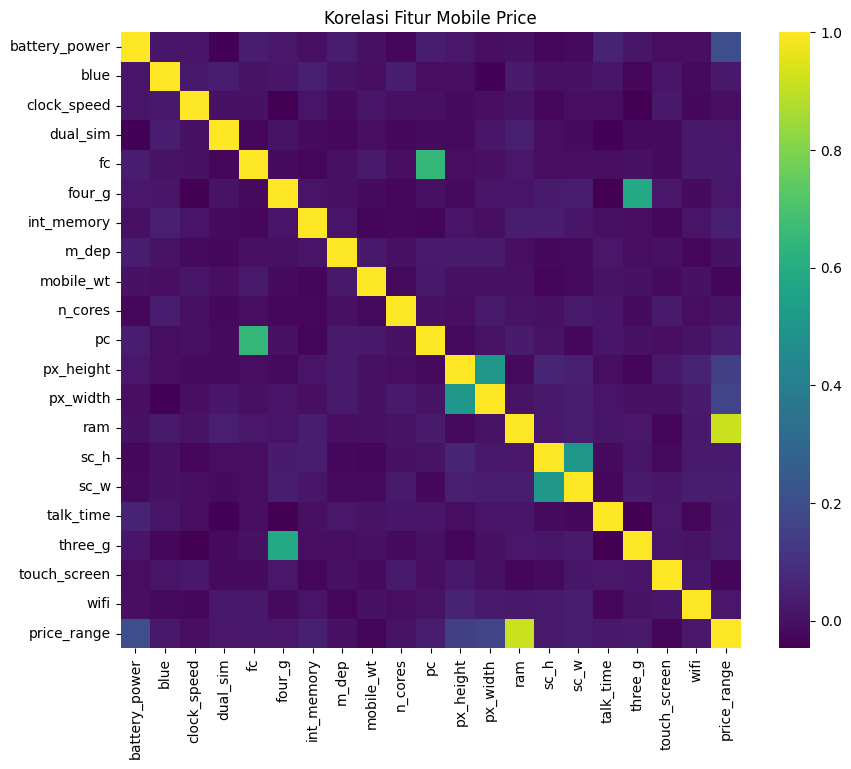

In [ ]:
missing_values = df.isnull().sum().max()
print(f"Total missing values tertinggi di satu kolom: {missing_values}")

print("\nDistribusi Kelas Target (price_range):")
print(df['price_range'].value_counts())

plt.figure(figsize=(10, 8))
top_corr_features = df.corr().index
sns.heatmap(df[top_corr_features].corr(), annot=False, cmap='viridis')
plt.title('Korelasi Fitur Mobile Price')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
print("--- 3. DATA PREPROCESSING ---")

df_clean_initial = df.dropna().drop_duplicates()
print(f"Bentuk data setelah pembersihan awal (hapus duplikat & NaN): {df_clean_initial.shape}")

X = df_clean_initial.drop('price_range', axis=1)
y = df_clean_initial['price_range']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\nPreprocessing Selesai. Tampilan data fitur yang sudah di-scale:")
display(X_scaled_df.head(3))

print("\n--- 4. SAVING PREPROCESSED DATA ---")
df_final = pd.concat([X_scaled_df, y.reset_index(drop=True)], axis=1)

clean_data_path = 'mobile_price_preprocessing/clean_mobile_price.csv'
df_final.to_csv(clean_data_path, index=False)

print(f"MANTAP! Dataset bersih siap di-training dan sudah disimpan di: {clean_data_path}")

--- 3. DATA PREPROCESSING ---
Bentuk data setelah pembersihan awal (hapus duplikat & NaN): (2000, 21)

Preprocessing Selesai. Tampilan data fitur yang sudah di-scale:


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,-0.902597,-0.990050,0.830779,-1.019184,-0.762495,-1.043966,-1.380644,0.340740,1.349249,-1.101971,-1.305750,-1.408949,-1.146784,0.391703,-0.784983,0.283103,1.462493,-1.786861,-1.006018,0.986097
1,-0.495139,1.010051,-1.253064,0.981177,-0.992890,0.957886,1.155024,0.687548,-0.120059,-0.664768,-0.645989,0.585778,1.704465,0.467317,1.114266,-0.635317,-0.734267,0.559641,0.994018,-1.014099
2,-1.537686,1.010051,-1.253064,0.981177,-0.532099,0.957886,0.493546,1.381165,0.134244,0.209639,-0.645989,1.392684,1.074968,0.441498,-0.310171,-0.864922,-0.368140,0.559641,0.994018,-1.014099



--- 4. SAVING PREPROCESSED DATA ---
MANTAP! Dataset bersih siap di-training dan sudah disimpan di: mobile_price_preprocessing/clean_mobile_price.csv
